# Лабораторная работа №1. Фреймворки Python для анализа данных

### Задачи:

- 1. Провести разведочный анализ данных (EDA) с использованием визуализации
- 2. Выполнить предобработку: обработка пропусков, коррекция выбросов, кодирование категориальных признаков, масштабирование
- 3. Отобрать релевантные признаки и обосновать выбор. Feature engineering 
- 4. Разделить данные на обучающую, валидационную и тестовую выборки без утечки данных
- 4. Обучить Linear Regression для задачи регрессии (спрогнозируйте CGPA успеваемость студента на основе его режима занятий и сна)
- 5. Обучить Logistic Regression для задачи классификации (определите, подвержен ли учащийся риску развития депрессии (столбец Depression), исходя из его образа жизни и уровня стресса). Поэкспериментируйте со значением шага обучения (learning rate) и числом эпох
- 6. Для логистической регрессии доказать отсутствие переобучения
- 7. Оценить качество моделей с использованием соответствующих метрик 
- 8. Сделать выводы о качестве моделей и влиянии этапов предобработки


### Подготовка и загрузка данных

In [2]:
# !!!
DATASET_CSV = ""

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, 
    f1_score, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("библиотеки загружены")

библиотеки загружены


In [4]:
# создание датафрейма
if DATASET_CSV:
    df = pd.read_csv(DATASET_CSV)
else:
    df = pd.read_csv('./data/dataset.csv')
    
print(f"размер: {df.shape}")
print(df.head())
print(df.isnull().sum())

размер: (100000, 11)
   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science  3.50             7.3          3.3   
1        1002   20    Male  Engineering  2.72             5.5          7.2   
2        1003   20    Male      Medical  3.01             5.4          2.3   
3        1004   21    Male  Engineering  3.63             8.1          2.0   
4        1005   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  
Student_ID            0
Age                   0
Gender                0
Department            0


### 1. Разведочный анализ данных EDA с использованием визуализации

Здесь мы визуально оцениваем распределение целевых переменных и связи признаков.

Исользуемые иинструменты:
- Гистограмма
- Корреляционная матрица




пропусков в данных не обнаружено


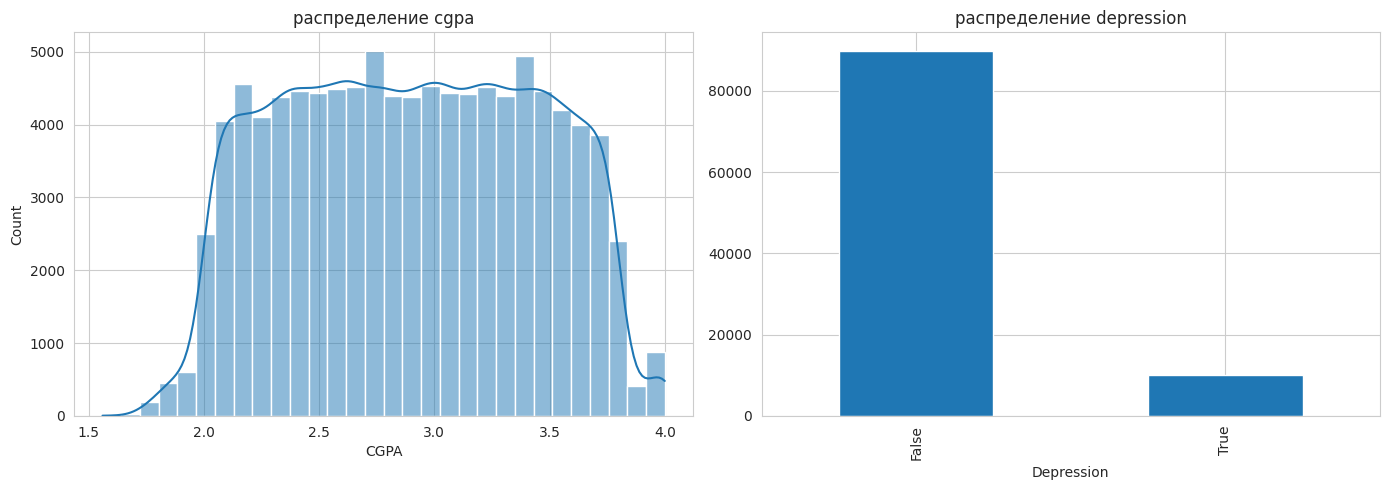

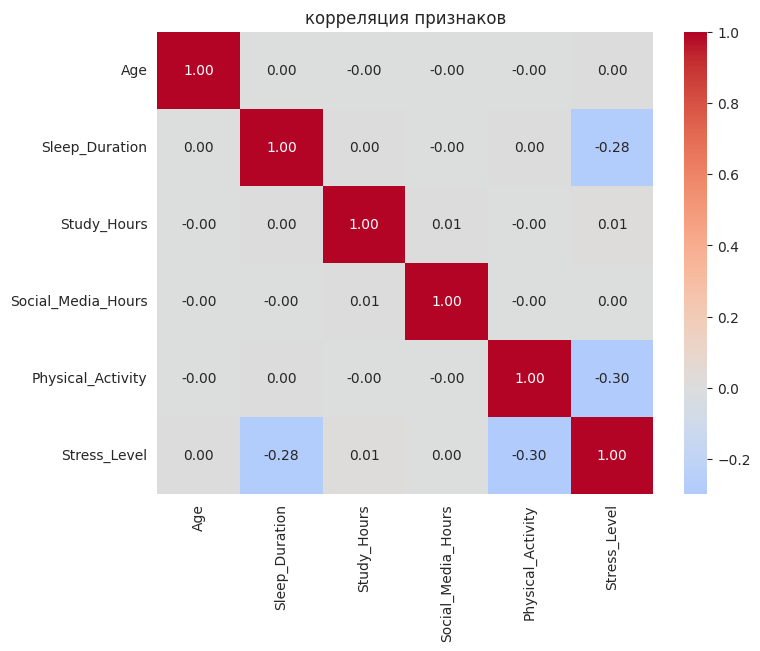

In [6]:
# Визуализация количества пропусков в столбцах
missing = df.isnull().sum()
missing = missing[missing > 0]  # оставляем только столбцы с пропусками

if len(missing) > 0:
    print(f"найдены пропуски в {len(missing)} столбцах:")
    print(missing.sort_values(ascending=False))
    
    plt.figure(figsize=(8, 4))
    missing.sort_values().plot(kind='barh', color='salmon')
    plt.xlabel('количество пропусков')
    plt.title('пропуски в данных')
    plt.tight_layout()
    plt.show()
else:
    print("пропусков в данных не обнаружено")

# Распределение целевых переменных
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['CGPA'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('распределение cgpa')
df['Depression'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('распределение depression')
plt.tight_layout()
plt.show()

# Корреляционная матрица
plt.figure(figsize=(8, 6))
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_cols = [c for c in num_cols if c not in ['Student_ID', 'CGPA', 'Depression']]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('корреляция признаков')
plt.show()

### 2. Предобработка данных
обработка пропусков, коррекция выбросов, кодирование категориальных признаков, масштабирование

In [9]:
# ПРЕДОБРАБОТКА!!!
df_proc = df.copy()

# 1. Удаление дубликатов
dup_count = df_proc.duplicated().sum()
df_proc = df_proc.drop_duplicates()
if dup_count == 0:
    print("Дупликатов НЕ ОБНАРУЖЕНО")
else:
    print(f"Удалено дупликатов: {dup_count}")

# 2. Исправление логических ошибок
neg_age = (df_proc['Age'] < 0).sum()
if neg_age > 0:
    df_proc.loc[df_proc['Age'] < 0, 'Age'] = df_proc.loc[df_proc['Age'] > 0, 'Age'].median()
    print(f"исправлен отрицательный возраст: {neg_age} записей")

df_proc['CGPA'] = df_proc['CGPA'].clip(0, 10)

# cgpa вне диапазона [0, 10]
cgpa_before = df_proc['CGPA'].copy()
df_proc['CGPA'] = df_proc['CGPA'].clip(0, 10)
cgpa_fixed = (cgpa_before != df_proc['CGPA']).sum()
if cgpa_fixed > 0:
    print(f"обрезан cgpa за пределы [0, 10]: {cgpa_fixed} записей")

# некорректное время (<0 или >24)
time_cols = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours']
nan_before = df_proc[time_cols].isnull().sum().sum()
for col in time_cols:
    mask = (df_proc[col] < 0) | (df_proc[col] > 24)
    df_proc.loc[mask, col] = np.nan
nan_fixed = df_proc[time_cols].isnull().sum().sum() - nan_before
if nan_fixed > 0:
    print(f"заменено на nan некорректных значений времени: {nan_fixed} записей")

# Замена некорректных значений времени на NaN
for col in ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours']:
    mask = (df_proc[col] < 0) | (df_proc[col] > 24)
    if mask.any():
        df_proc.loc[mask, col] = np.nan

# 3. Заполнение пропусков
miss_before = df_proc.isnull().sum().sum()
for col in df_proc.select_dtypes(include=np.number).columns:
    df_proc[col] = df_proc[col].fillna(df_proc[col].median())
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = df_proc[col].fillna(df_proc[col].mode()[0])
miss_fixed = miss_before - df_proc.isnull().sum().sum()
print(f"заполнено пропусков: {miss_fixed} (числовые -> медиана, категориальные -> мода)")


# 4. обработка выбросов (iqr метод)
outlier_cols = ['CGPA', 'Sleep_Duration', 'Study_Hours', 'Stress_Level']
for col in outlier_cols:
    q1, q3 = df_proc[col].quantile(0.25), df_proc[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers_count = ((df_proc[col] < lower) | (df_proc[col] > upper)).sum()
    df_proc[col] = df_proc[col].clip(lower, upper)
    if outliers_count > 0:
        print(f"обработано выбросов в {col}: {outliers_count}")

print(f"\nитого: исходно {len(df)} строк -> после очистки {len(df_proc)}")

Дупликатов НЕ ОБНАРУЖЕНО
заполнено пропусков: 0 (числовые -> медиана, категориальные -> мода)
обработано выбросов в Sleep_Duration: 369
обработано выбросов в Study_Hours: 432
обработано выбросов в Stress_Level: 478

итого: исходно 100000 строк -> после очистки 100000


### 3. Feature Engineering.

In [11]:
# Создание новых признаков
df_proc['Study_Social_Ratio'] = df_proc['Study_Hours'] / (df_proc['Social_Media_Hours'] + 1)
df_proc['Health_Index'] = df_proc['Physical_Activity'] + (10 - df_proc['Stress_Level'])
df_proc['Adequate_Sleep'] = ((df_proc['Sleep_Duration'] >= 7) & (df_proc['Sleep_Duration'] <= 9)).astype(int)

# Кодирование категориальных признаков
if 'Department' in df_proc.columns:
    df_proc = pd.get_dummies(df_proc, columns=['Department'], prefix='Dept', drop_first=True)

if 'Gender' in df_proc.columns and df_proc['Gender'].dtype == 'object':
    df_proc['Gender_Encoded'] = df_proc['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)

# Списки признаков для моделей
feat_reg = ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 
            'Physical_Activity', 'Stress_Level', 'Study_Social_Ratio', 
            'Health_Index', 'Adequate_Sleep']
            
feat_clf = feat_reg + ['CGPA']

for col in df_proc.columns:
    if col.startswith('Dept_') or col == 'Gender_Encoded':
        if col not in feat_reg: feat_reg.append(col)
        if col not in feat_clf: feat_clf.append(col)

### 4. Разделение данных на обучающую, валидационную и тестовую выборки
а также масштабирование признаков относительно друг друга

In [12]:
# --- Регрессия (CGPA) ---
X_reg = df_proc[feat_reg]
y_reg = df_proc['CGPA']
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(X_te_r, y_te_r, test_size=0.5, random_state=42)

# --- Классификация (Depression) ---
X_clf = df_proc[feat_clf]
y_clf = df_proc['Depression']
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(X_te_c, y_te_c, test_size=0.5, random_state=42, stratify=y_te_c)

# Масштабирование (fit на train, transform на val/test)
scaler_r = StandardScaler().fit(X_tr_r)
X_tr_r_s = scaler_r.transform(X_tr_r)
X_val_r_s = scaler_r.transform(X_val_r)
X_test_r_s = scaler_r.transform(X_test_r)

scaler_c = StandardScaler().fit(X_tr_c)
X_tr_c_s = scaler_c.transform(X_tr_c)
X_val_c_s = scaler_c.transform(X_val_c)
X_test_c_s = scaler_c.transform(X_test_c)

### 5. Обучение Linear Regression для задачи регрессии (прогнозирование CGPA успеваемость студента на основе его режима занятий и сна)

r2 score: 0.0196
rmse: 0.5302


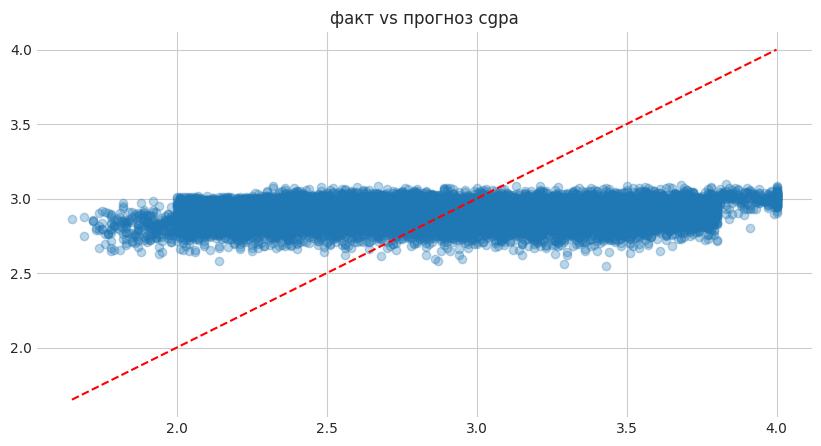

In [65]:
lr = LinearRegression().fit(X_tr_r_s, y_tr_r)
pred_test = lr.predict(X_test_r_s)

print(f"r2 score: {r2_score(y_test_r, pred_test):.4f}")
print(f"rmse: {np.sqrt(mean_squared_error(y_test_r, pred_test)):.4f}")

plt.scatter(y_test_r, pred_test, alpha=0.3)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.title('факт vs прогноз cgpa')
plt.show()

### Обучение Logistic Regression для задачи классификации (подвержен ли учащийся риску развития депрессии (столбец Depression), исходя из его образа жизни и уровня стресса).
Экспериментирую с регуляризацией и числом эпох

In [23]:
# Подбор гиперпараметров
best_c, best_iter = 1, 100
best_acc = 0

for c in [0.0001, 0.0005, 0.001, 0.01, 0.1, 1, 5, 10, 100]: # эксперимент с регуляризацией
    for it in [100, 500000]: # эксперимент с числом эпох
        m = LogisticRegression(C=c, max_iter=int(it), solver='lbfgs', random_state=42)
        m.fit(X_tr_c_s, y_tr_c)
        acc = accuracy_score(y_val_c, m.predict(X_val_c_s))
        if acc > best_acc:
            best_acc = acc
            best_c, best_iter = c, int(it)

# Обучение финальной модели
clf = LogisticRegression(C=best_c, max_iter=best_iter, solver='lbfgs', random_state=42)
clf.fit(X_tr_c_s, y_tr_c)

pred_cls = clf.predict(X_test_c_s)
pred_proba = clf.predict_proba(X_test_c_s)[:, 1]

print(f"accuracy: {accuracy_score(y_test_c, pred_cls):.4f}")
print(f"f1 score: {f1_score(y_test_c, pred_cls):.4f}")
print(f"roc-auc: {roc_auc_score(y_test_c, pred_proba):.4f}")
print(classification_report(y_test_c, pred_cls))
print(f"\nbest c: {best_c}")
print(f"best c: {best_iter}")



accuracy: 0.8994
f1 score: 0.0000
roc-auc: 0.6852
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     13491
        True       0.00      0.00      0.00      1509

    accuracy                           0.90     15000
   macro avg       0.45      0.50      0.47     15000
weighted avg       0.81      0.90      0.85     15000


best c: 0.0001
best c: 100


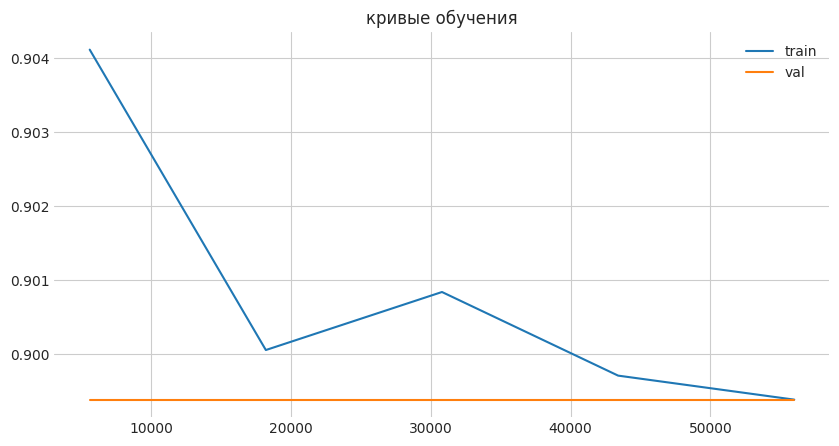

точность на train: 0.8994
точность на test: 0.8994
переобучения нет


In [55]:
# Кривые обучения
train_sizes, train_scores, val_scores = learning_curve(
    clf, X_tr_c_s, y_tr_c, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='val')
plt.title('кривые обучения')
plt.legend()
plt.show()

# Сравнение метрик
train_acc = accuracy_score(y_tr_c, clf.predict(X_tr_c_s))
test_acc = accuracy_score(y_test_c, pred_cls)

print(f"точность на train: {train_acc:.4f}")
print(f"точность на test: {test_acc:.4f}")

if abs(train_acc - test_acc) < 0.05:
    print("переобучения нет")
else:
    print("возможно переобучение")

### Ручное тестирование

In [67]:
# Данные нового студента
input_data = {
    'Age': 20,
    'Gender': 'Male',
    'Department': 'Computer Science',
    'Sleep_Duration': 7.0,
    'Study_Hours': 5.0,
    'Social_Media_Hours': 2.0,
    'Physical_Activity': 3.0,
    'Stress_Level': 6.0
}

new_student = pd.DataFrame([input_data])

# 1. Кодирование и Feature Engineering (повторяем логику из Ячейки 4)
if 'Department' in new_student.columns:
    new_student = pd.get_dummies(new_student, columns=['Department'], prefix='Dept', drop_first=True)

if 'Gender' in new_student.columns:
    new_student['Gender_Encoded'] = new_student['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)
    new_student.drop(columns=['Gender'], inplace=True, errors='ignore')

new_student['Study_Social_Ratio'] = new_student['Study_Hours'] / (new_student['Social_Media_Hours'] + 1)
new_student['Health_Index'] = new_student['Physical_Activity'] + (10 - new_student['Stress_Level'])
new_student['Adequate_Sleep'] = ((new_student['Sleep_Duration'] >= 7) & (new_student['Sleep_Duration'] <= 9)).astype(int)

# 2. Выравнивание столбцов (добавляем недостающие нулями)
for col in feat_reg:
    if col not in new_student.columns:
        new_student[col] = 0
for col in feat_clf:
    if col not in new_student.columns:
        new_student[col] = 0

# Отбираем нужные колонки в правильном порядке
X_new_r = new_student[feat_reg]
X_new_c = new_student[feat_clf]

# 3. Масштабирование (используем уже обученные scaler)
X_new_r_s = scaler_r.transform(X_new_r)
X_new_c_s = scaler_c.transform(X_new_c)

# 4. Прогноз
pred_cgpa = lr.predict(X_new_r_s)[0]
pred_dep_class = clf.predict(X_new_c_s)[0]
pred_dep_prob = clf.predict_proba(X_new_c_s)[0][1]

print(f"прогноз cgpa: {pred_cgpa:.2f}")
print(f"риск депрессии: {'да' if pred_dep_class == 1 else 'нет'} (вероятность {pred_dep_prob:.2%})")

прогноз cgpa: 2.96
риск депрессии: да (вероятность 79.67%)
